# Section 7: Selecting Loss Functions

In [1]:
# ============================================================
# Section 7: Selecting Loss Functions
# Fresh Start: Load Titanic and LendingClub from OpenML
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, HuberRegressor
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    log_loss,
    hinge_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    classification_report
)

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [2]:
# 1. Load Titanic Dataset from OpenML

print('Fetching Titanic dataset from OpenML...')
titanic = fetch_openml(name='titanic', version=1, as_frame=True, parser='auto')
titanic_df = titanic.frame

# 2. Load LendingClub Dataset via OpenML

print('Fetching LendingClub dataset from OpenML...')
lending = fetch_openml(name='lending-club-loan-data', version=1, as_frame=True, parser='auto')
lending_df = lending.frame

print('Datasets loaded successfully!')

Fetching Titanic dataset from OpenML...
Fetching LendingClub dataset from OpenML...
Datasets loaded successfully!


## Titanic Dataset

Titanic is a binary classification problem.

Target:

- `survived = 0`: did not survive
- `survived = 1`: survived

For binary classification, common losses include:

1. Binary cross-entropy / log loss  
2. Hinge loss  
3. Weighted loss for imbalance  

In [3]:
# ============================================================
# 7A. Prepare Titanic Dataset
# ============================================================

titanic_model = titanic_df.copy()

titanic_target = "survived"

# Convert target to integer
titanic_model[titanic_target] = titanic_model[titanic_target].astype(int)

# Treat pclass as categorical
if "pclass" in titanic_model.columns:
    titanic_model["pclass"] = titanic_model["pclass"].astype("category")

# Separate features and target FIRST
X_titanic = titanic_model.drop(columns=[titanic_target]).copy()
y_titanic = titanic_model[titanic_target].copy()

# Drop columns that are not useful or may cause leakage
cols_to_drop = ["name", "ticket", "cabin", "boat", "body", "home.dest"]
X_titanic = X_titanic.drop(columns=cols_to_drop, errors="ignore")

# Identify categorical and numeric columns
cat_cols = X_titanic.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_titanic.select_dtypes(include=[np.number]).columns.tolist()

# Clean categorical columns
for col in cat_cols:
    X_titanic[col] = X_titanic[col].astype("object")
    X_titanic[col] = X_titanic[col].fillna("missing")
    X_titanic[col] = X_titanic[col].astype(str).str.strip().str.lower()

# Impute numeric columns
num_imputer = SimpleImputer(strategy="median")
X_titanic[num_cols] = num_imputer.fit_transform(X_titanic[num_cols])

# One-hot encode categorical columns
X_titanic = pd.get_dummies(
    X_titanic,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

print("Titanic X shape:", X_titanic.shape)
print("Titanic y shape:", y_titanic.shape)

display(X_titanic.head())
display(y_titanic.value_counts(normalize=True))

Titanic X shape: (1309, 10)
Titanic y shape: (1309,)


,age,sibsp,parch,fare,pclass_2,pclass_3,sex_male,embarked_missing,embarked_q,embarked_s
0,29.0000,0.0,0.0,211.3375,0,0,0,0,0,1
1,0.9167,1.0,2.0,151.5500,0,0,1,0,0,1
2,2.0000,1.0,2.0,151.5500,0,0,0,0,0,1
3,30.0000,1.0,2.0,151.5500,0,0,1,0,0,1
4,25.0000,1.0,2.0,151.5500,0,0,0,0,0,1


survived
0    0.618029
1    0.381971
Name: proportion, dtype: float64

In [4]:
# Train-test split

X_train_titanic, X_test_titanic, y_train_titanic, y_test_titanic = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.2,
    random_state=42,
    stratify=y_titanic
)

print("Train shape:", X_train_titanic.shape)
print("Test shape:", X_test_titanic.shape)

Train shape: (1047, 10)
Test shape: (262, 10)


### Log Loss / Binary Cross-Entropy

Logistic Regression minimizes log loss.

Log loss penalizes confident wrong predictions heavily.

Example:

- Predict 0.51 for the correct class: small penalty
- Predict 0.99 for the wrong class: very large penalty

In [5]:
# Logistic Regression uses log loss

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train_titanic, y_train_titanic)

y_pred_titanic = logistic_model.predict(X_test_titanic)
y_proba_titanic = logistic_model.predict_proba(X_test_titanic)[:, 1]

titanic_log_loss = log_loss(y_test_titanic, y_proba_titanic)

print("Titanic Logistic Regression")
print("Log Loss:", titanic_log_loss)
print("Accuracy:", accuracy_score(y_test_titanic, y_pred_titanic))
print("Precision:", precision_score(y_test_titanic, y_pred_titanic))
print("Recall:", recall_score(y_test_titanic, y_pred_titanic))
print("F1:", f1_score(y_test_titanic, y_pred_titanic))
print("ROC-AUC:", roc_auc_score(y_test_titanic, y_proba_titanic))

Titanic Logistic Regression
Log Loss: 0.4334104328692562
Accuracy: 0.8053435114503816
Precision: 0.7634408602150538
Recall: 0.71
F1: 0.7357512953367875
ROC-AUC: 0.8672530864197531


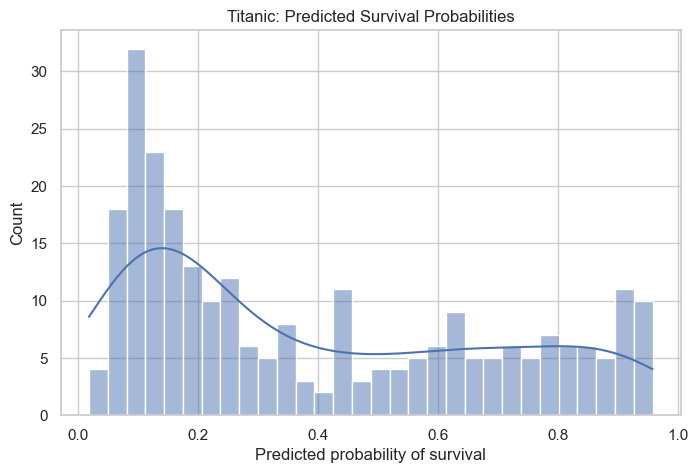

In [6]:
# Visualize predicted probabilities

plt.figure(figsize=(8, 5))
sns.histplot(y_proba_titanic, bins=30, kde=True)
plt.title("Titanic: Predicted Survival Probabilities")
plt.xlabel("Predicted probability of survival")
plt.ylabel("Count")
plt.show()

### Manual Log Loss Example

This shows why confident wrong predictions are heavily penalized.

,actual,predicted_probability,individual_log_loss
0,1,0.9,0.105361
1,1,0.6,0.510826
2,1,0.1,2.302585
3,0,0.1,0.105361
4,0,0.4,0.510826
5,0,0.9,2.302585


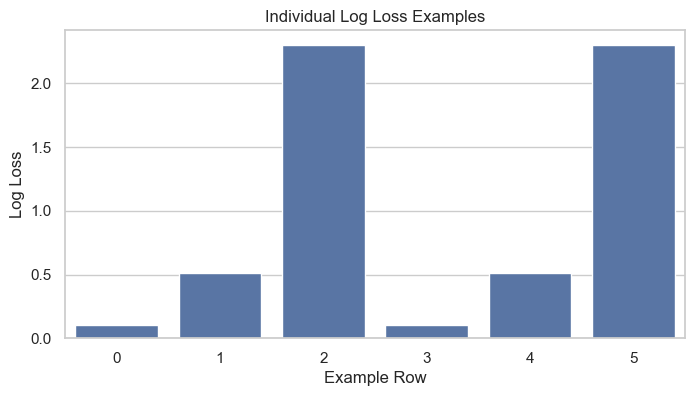

In [8]:
# Manual log loss demonstration

example = pd.DataFrame({
    "actual": [1, 1, 1, 0, 0, 0],
    "predicted_probability": [0.90, 0.60, 0.10, 0.10, 0.40, 0.90]
})

epsilon = 1e-15

example["individual_log_loss"] = -(
    example["actual"] * np.log(example["predicted_probability"] + epsilon)
    + (1 - example["actual"]) * np.log(1 - example["predicted_probability"] + epsilon)
)

display(example)

plt.figure(figsize=(8, 4))
sns.barplot(data=example, x=example.index, y="individual_log_loss")
plt.title("Individual Log Loss Examples")
plt.xlabel("Example Row")
plt.ylabel("Log Loss")
plt.show()

### Hinge Loss

SVM models commonly use hinge loss.

Hinge loss focuses on separating classes with a margin.

In [9]:
# Linear SVM uses hinge-style loss

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearSVC(random_state=42, max_iter=5000))
])

svm_model.fit(X_train_titanic, y_train_titanic)

y_pred_svm = svm_model.predict(X_test_titanic)
y_score_svm = svm_model.decision_function(X_test_titanic)

# hinge_loss expects labels as -1 and +1 or binary with decision scores
titanic_hinge_loss = hinge_loss(y_test_titanic, y_score_svm)

print("Titanic Linear SVM")
print("Hinge Loss:", titanic_hinge_loss)
print("Accuracy:", accuracy_score(y_test_titanic, y_pred_svm))
print("Precision:", precision_score(y_test_titanic, y_pred_svm))
print("Recall:", recall_score(y_test_titanic, y_pred_svm))
print("F1:", f1_score(y_test_titanic, y_pred_svm))

Titanic Linear SVM
Hinge Loss: 0.5767050216609614
Accuracy: 0.816793893129771
Precision: 0.776595744680851
Recall: 0.73
F1: 0.7525773195876289


### Weighted Loss for Imbalanced Classification

Weighted loss gives more importance to the minority class.

In scikit-learn, this is often done using:

```python
class_weight="balanced"
```

In [11]:
# Compare normal logistic regression vs class-weighted logistic regression

models = {
    "Logistic Regression - Normal Loss": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    
    "Logistic Regression - Weighted Loss": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ])
}

loss_results = []

for model_name, model in models.items():
    model.fit(X_train_titanic, y_train_titanic)
    
    preds = model.predict(X_test_titanic)
    proba = model.predict_proba(X_test_titanic)[:, 1]
    
    loss_results.append({
        "model": model_name,
        "log_loss": log_loss(y_test_titanic, proba),
        "accuracy": accuracy_score(y_test_titanic, preds),
        "precision": precision_score(y_test_titanic, preds),
        "recall": recall_score(y_test_titanic, preds),
        "f1": f1_score(y_test_titanic, preds),
        "roc_auc": roc_auc_score(y_test_titanic, proba)
    })

titanic_loss_results = pd.DataFrame(loss_results)

display(titanic_loss_results)

,model,log_loss,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression - Normal Loss,0.433410,0.805344,0.763441,0.71,0.735751,0.867253
1,Logistic Regression - Weighted Loss,0.458297,0.790076,0.702703,0.78,0.739336,0.866636


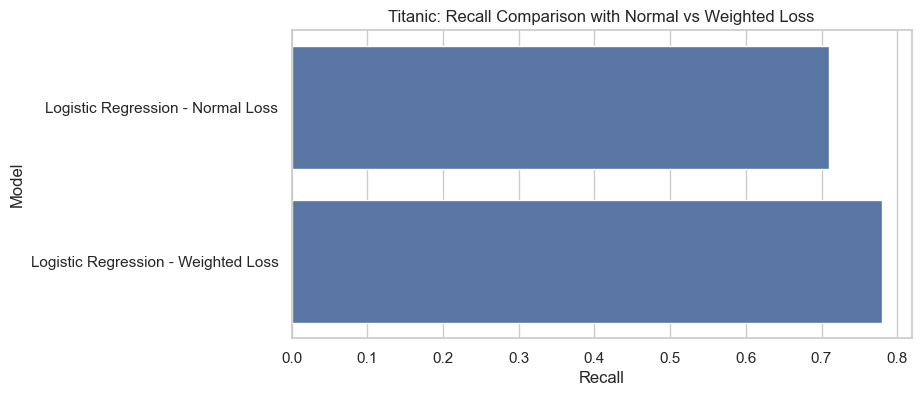

In [12]:
plt.figure(figsize=(8, 4))
sns.barplot(data=titanic_loss_results, x="recall", y="model")
plt.title("Titanic: Recall Comparison with Normal vs Weighted Loss")
plt.xlabel("Recall")
plt.ylabel("Model")
plt.show()

## LendingClub

LendingClub is a binary classification problem.

Target:

- `not_fully_paid = 0`: fully paid
- `not_fully_paid = 1`: not fully paid

This dataset is usually imbalanced, so weighted loss is especially important.

In [14]:
# ============================================================
# 7B. Prepare LendingClub Dataset
# ============================================================

lc_model = lending_df.copy()

lc_target = "not.fully.paid"

# Convert target to integer
lc_model[lc_target] = lc_model[lc_target].astype(int)

# Separate features and target FIRST
X_lc = lc_model.drop(columns=[lc_target]).copy()
y_lc = lc_model[lc_target].copy()

# Identify categorical and numeric columns
cat_cols = X_lc.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_lc.select_dtypes(include=[np.number]).columns.tolist()

# Clean categorical columns
for col in cat_cols:
    X_lc[col] = X_lc[col].astype("object")
    X_lc[col] = X_lc[col].fillna("missing")
    X_lc[col] = X_lc[col].astype(str).str.strip().str.lower()

# Impute numeric columns
num_imputer = SimpleImputer(strategy="median")
X_lc[num_cols] = num_imputer.fit_transform(X_lc[num_cols])

# One-hot encode categorical columns
X_lc = pd.get_dummies(
    X_lc,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

# Handle infinite or missing values after transformations
X_lc = X_lc.replace([np.inf, -np.inf], np.nan)
X_lc = X_lc.fillna(X_lc.median(numeric_only=True))

print("LendingClub X shape:", X_lc.shape)
print("LendingClub y shape:", y_lc.shape)

display(X_lc.head())
display(y_lc.value_counts(normalize=True))

LendingClub X shape: (9578, 18)
LendingClub y shape: (9578,)


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1.0,0.1189,829.10,11.350407,19.48,737.0,5639.958333,28854.0,52.1,0.0,0.0,0.0,0,1,0,0,0,0
1,1.0,0.1071,228.22,11.082143,14.29,707.0,2760.000000,33623.0,76.7,0.0,0.0,0.0,1,0,0,0,0,0
2,1.0,0.1357,366.86,10.373491,11.63,682.0,4710.000000,3511.0,25.6,1.0,0.0,0.0,0,1,0,0,0,0
3,1.0,0.1008,162.34,11.350407,8.10,712.0,2699.958333,33667.0,73.2,1.0,0.0,0.0,0,1,0,0,0,0
4,1.0,0.1426,102.92,11.299732,14.97,667.0,4066.000000,4740.0,39.5,0.0,1.0,0.0,1,0,0,0,0,0


not.fully.paid
0    0.839946
1    0.160054
Name: proportion, dtype: float64

In [15]:
# Train-test split

X_train_lc, X_test_lc, y_train_lc, y_test_lc = train_test_split(
    X_lc,
    y_lc,
    test_size=0.2,
    random_state=42,
    stratify=y_lc
)

print("Train shape:", X_train_lc.shape)
print("Test shape:", X_test_lc.shape)

Train shape: (7662, 18)
Test shape: (1916, 18)


### Normal Log Loss vs Weighted Log Loss

For LendingClub, missing the risky class can be expensive.

Weighted loss can increase attention to `not_fully_paid = 1`.

In [16]:
lc_loss_models = {
    "Logistic Regression - Normal Loss": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    
    "Logistic Regression - Weighted Loss": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ])
}

lc_loss_results = []

for model_name, model in lc_loss_models.items():
    model.fit(X_train_lc, y_train_lc)
    
    preds = model.predict(X_test_lc)
    proba = model.predict_proba(X_test_lc)[:, 1]
    
    lc_loss_results.append({
        "model": model_name,
        "log_loss": log_loss(y_test_lc, proba),
        "accuracy": accuracy_score(y_test_lc, preds),
        "precision": precision_score(y_test_lc, preds, zero_division=0),
        "recall": recall_score(y_test_lc, preds, zero_division=0),
        "f1": f1_score(y_test_lc, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_test_lc, proba)
    })

lc_loss_results = pd.DataFrame(lc_loss_results)

display(lc_loss_results)

,model,log_loss,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression - Normal Loss,0.409194,0.840292,0.518519,0.045603,0.083832,0.683387
1,Logistic Regression - Weighted Loss,0.634011,0.640397,0.239071,0.570033,0.336862,0.684468


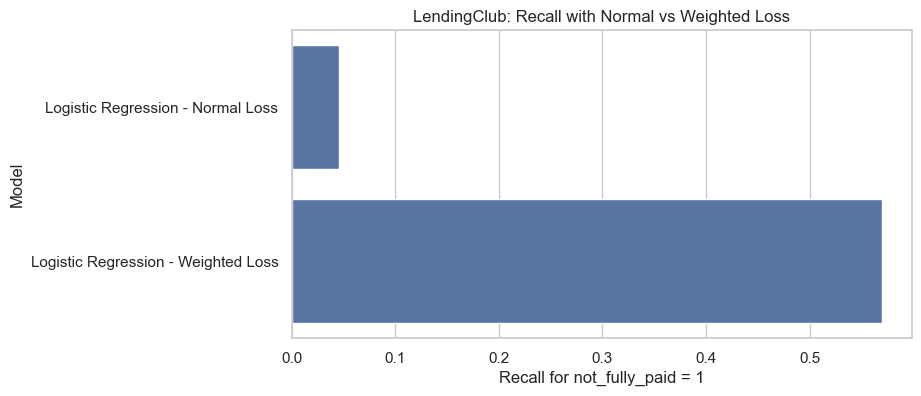

In [17]:
plt.figure(figsize=(8, 4))
sns.barplot(data=lc_loss_results, x="recall", y="model")
plt.title("LendingClub: Recall with Normal vs Weighted Loss")
plt.xlabel("Recall for not_fully_paid = 1")
plt.ylabel("Model")
plt.show()

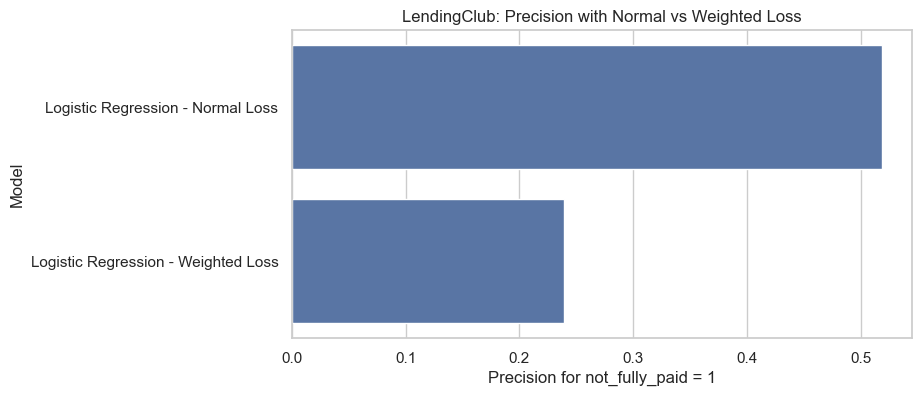

In [18]:
plt.figure(figsize=(8, 4))
sns.barplot(data=lc_loss_results, x="precision", y="model")
plt.title("LendingClub: Precision with Normal vs Weighted Loss")
plt.xlabel("Precision for not_fully_paid = 1")
plt.ylabel("Model")
plt.show()

### Hinge Loss with Linear SVM

Linear SVM uses hinge loss.

This can be useful when we care about separating classes with a margin.

In [19]:
lc_svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearSVC(
        random_state=42,
        max_iter=5000,
        class_weight="balanced"
    ))
])

lc_svm_model.fit(X_train_lc, y_train_lc)

y_pred_lc_svm = lc_svm_model.predict(X_test_lc)
y_score_lc_svm = lc_svm_model.decision_function(X_test_lc)

lc_hinge_loss = hinge_loss(y_test_lc, y_score_lc_svm)

print("LendingClub Linear SVM")
print("Hinge Loss:", lc_hinge_loss)
print(classification_report(y_test_lc, y_pred_lc_svm))

LendingClub Linear SVM
Hinge Loss: 0.8897619269782203
              precision    recall  f1-score   support

           0       0.89      0.66      0.76      1609
           1       0.24      0.58      0.34       307

    accuracy                           0.64      1916
   macro avg       0.57      0.62      0.55      1916
weighted avg       0.79      0.64      0.69      1916



In [20]:
def business_cost_loss(y_true, y_pred, false_negative_cost=5, false_positive_cost=1):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    false_negatives = ((y_true == 1) & (y_pred == 0)).sum()
    false_positives = ((y_true == 0) & (y_pred == 1)).sum()
    
    total_cost = (
        false_negatives * false_negative_cost
        + false_positives * false_positive_cost
    )
    
    return {
        "false_negatives": false_negatives,
        "false_positives": false_positives,
        "total_business_cost": total_cost
    }

In [21]:
business_cost_results = []

for model_name, model in lc_loss_models.items():
    preds = model.predict(X_test_lc)
    
    cost = business_cost_loss(
        y_test_lc,
        preds,
        false_negative_cost=5,
        false_positive_cost=1
    )
    
    business_cost_results.append({
        "model": model_name,
        **cost
    })

business_cost_results = pd.DataFrame(business_cost_results)

display(business_cost_results)

,model,false_negatives,false_positives,total_business_cost
0,Logistic Regression - Normal Loss,293,13,1478
1,Logistic Regression - Weighted Loss,132,557,1217


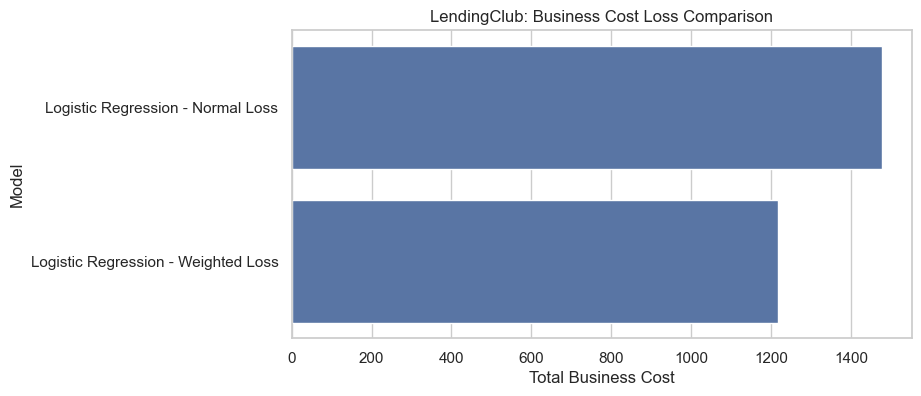

In [22]:
plt.figure(figsize=(8, 4))
sns.barplot(data=business_cost_results, x="total_business_cost", y="model")
plt.title("LendingClub: Business Cost Loss Comparison")
plt.xlabel("Total Business Cost")
plt.ylabel("Model")
plt.show()

## Regression Loss Functions

The deck also mentions regression losses:

1. MSE  
2. MAE  
3. Huber Loss  

Titanic and LendingClub targets are classification targets, so we create a small regression example using Titanic `fare`.

Target:

- Predict `fare`

This lets us compare MSE, MAE, and Huber behavior.

In [23]:
# ============================================================
# 7C. Regression Loss Example Using Titanic Fare
# ============================================================

reg_df = titanic_df.copy()

reg_target = "fare"

# Drop rows where fare is missing
reg_df = reg_df.dropna(subset=[reg_target])

# Treat pclass as categorical
if "pclass" in reg_df.columns:
    reg_df["pclass"] = reg_df["pclass"].astype("category")

# Separate X and y
X_reg = reg_df.drop(columns=[reg_target]).copy()
y_reg = reg_df[reg_target].astype(float).copy()

# Drop columns not useful for simple regression demo
cols_to_drop = ["name", "ticket", "cabin", "boat", "body", "home.dest"]
X_reg = X_reg.drop(columns=cols_to_drop, errors="ignore")

# Drop survived from predictors to avoid mixing target-like variable
X_reg = X_reg.drop(columns=["survived"], errors="ignore")

# Identify columns
cat_cols = X_reg.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_reg.select_dtypes(include=[np.number]).columns.tolist()

# Clean categorical
for col in cat_cols:
    X_reg[col] = X_reg[col].astype("object")
    X_reg[col] = X_reg[col].fillna("missing")
    X_reg[col] = X_reg[col].astype(str).str.strip().str.lower()

# Impute numeric
num_imputer = SimpleImputer(strategy="median")
X_reg[num_cols] = num_imputer.fit_transform(X_reg[num_cols])

# One-hot encode
X_reg = pd.get_dummies(
    X_reg,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

print("Regression X shape:", X_reg.shape)
print("Regression y shape:", y_reg.shape)

Regression X shape: (1308, 9)
Regression y shape: (1308,)


In [24]:
# Train-test split for regression

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

### Compare MSE, MAE, and Huber Models

- Linear Regression often minimizes MSE.
- MAE is less sensitive to large errors than MSE.
- Huber loss combines MSE and MAE behavior.

In [25]:
regression_models = {
    "Linear Regression - MSE style": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Ridge Regression - MSE + regularization": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    
    "Huber Regressor - robust loss": Pipeline([
        ("scaler", StandardScaler()),
        ("model", HuberRegressor())
    ])
}

regression_results = []

for model_name, model in regression_models.items():
    model.fit(X_train_reg, y_train_reg)
    preds = model.predict(X_test_reg)
    
    regression_results.append({
        "model": model_name,
        "mse": mean_squared_error(y_test_reg, preds),
        "rmse": np.sqrt(mean_squared_error(y_test_reg, preds)),
        "mae": mean_absolute_error(y_test_reg, preds),
        "r2": r2_score(y_test_reg, preds)
    })

regression_results = pd.DataFrame(regression_results).sort_values("mae")

display(regression_results)

,model,mse,rmse,mae,r2
1,Ridge Regression - MSE + regularization,1539.252870,39.233313,19.507654,0.420364
0,Linear Regression - MSE style,1539.617000,39.237954,19.522715,0.420227
2,Huber Regressor - robust loss,1742.430095,41.742426,15.077553,0.343854


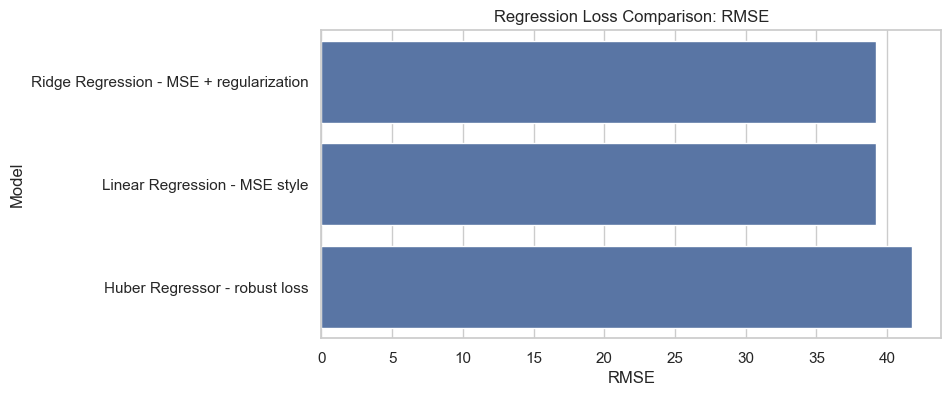

In [26]:
plt.figure(figsize=(8, 4))
sns.barplot(data=regression_results, x="rmse", y="model")
plt.title("Regression Loss Comparison: RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.show()

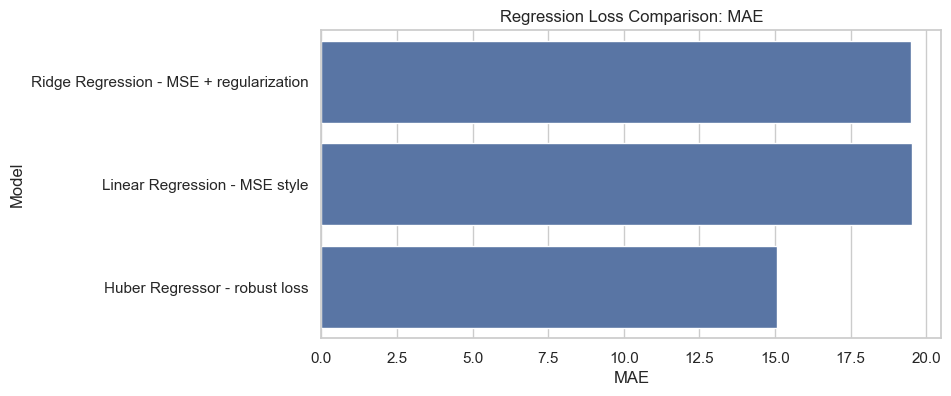

In [27]:
plt.figure(figsize=(8, 4))
sns.barplot(data=regression_results, x="mae", y="model")
plt.title("Regression Loss Comparison: MAE")
plt.xlabel("MAE")
plt.ylabel("Model")
plt.show()

In [28]:
loss_recommendations = pd.DataFrame({
    "problem_type": [
        "Regression",
        "Regression with outliers",
        "Binary classification",
        "Multiclass classification",
        "SVM classification",
        "Imbalanced classification",
        "Business-cost-sensitive classification"
    ],
    "recommended_loss": [
        "MSE / RMSE",
        "MAE or Huber Loss",
        "Binary Cross-Entropy / Log Loss",
        "Categorical Cross-Entropy",
        "Hinge Loss",
        "Weighted Loss or Focal Loss",
        "Custom Cost-Based Loss"
    ],
    "example_model": [
        "Linear Regression, Ridge, XGBoost Regressor",
        "HuberRegressor, Robust Regression",
        "Logistic Regression, Neural Network, Gradient Boosting",
        "Multinomial Logistic Regression, Neural Network",
        "SVM / LinearSVC",
        "Logistic Regression with class_weight='balanced'",
        "Threshold tuning or custom objective"
    ],
    "when_to_use": [
        "When large errors should be penalized heavily",
        "When data has extreme outliers",
        "When predicting probability of class 1",
        "When target has more than two classes",
        "When maximizing class separation margin",
        "When minority class is important",
        "When false positives and false negatives have different business costs"
    ]
})

display(loss_recommendations)

,problem_type,recommended_loss,example_model,when_to_use
0,Regression,MSE / RMSE,"Linear Regression, Ridge, XGBoost Regressor",When large errors should be penalized heavily
1,Regression with outliers,MAE or Huber Loss,"HuberRegressor, Robust Regression",When data has extreme outliers
2,Binary classification,Binary Cross-Entropy / Log Loss,"Logistic Regression, Neural Network, Gradient ...",When predicting probability of class 1
3,Multiclass classification,Categorical Cross-Entropy,"Multinomial Logistic Regression, Neural Network",When target has more than two classes
4,SVM classification,Hinge Loss,SVM / LinearSVC,When maximizing class separation margin
5,Imbalanced classification,Weighted Loss or Focal Loss,Logistic Regression with class_weight='balanced',When minority class is important
6,Business-cost-sensitive classification,Custom Cost-Based Loss,Threshold tuning or custom objective,When false positives and false negatives have ...


## Section 7 Summary

Key ideas:

- Logistic Regression uses log loss / binary cross-entropy.
- SVM uses hinge loss.
- Linear regression commonly uses MSE.
- Huber loss is useful when outliers are present.
- For imbalanced data, weighted loss can improve minority-class recall.
- For business problems, the best loss may depend on the cost of false positives and false negatives.

For Titanic:

- Normal log loss is a good starting point.
- Weighted loss can be tested if one class matters more.

For LendingClub:

- Weighted loss is important because not_fully_paid = 1 is the risky class.
- Business cost loss may be more meaningful than accuracy.